# Huấn luyện Custom PPO (Scratch) trên Atari Pong

Sổ tay này hướng dẫn huấn luyện mô hình **PPO (Proximal Policy Optimization)** tự phát triển bằng PyTorch trên Pong.

## Giới thiệu thuật toán và kiến trúc mô hình

### 1. Thuật toán PPO
PPO (Proximal Policy Optimization) là một thuật toán học tăng cường On-Policy thuộc họ Policy Gradient (độ dốc chính sách). PPO nổi tiếng nhờ tính ổn định cực cao và hiệu quả vượt trội trong thực tế.

Các đặc tính cốt lõi bao gồm:
- **Clipped Surrogate Objective**: Hàm mục tiêu của chính sách giới hạn mức độ cập nhật của mạng nơ-ron mới so với mạng cũ bằng cách sử dụng phép xấp xỉ tỉ lệ xác suất hành động $r_t(\theta) = \frac{\pi_\theta(a_t | s_t)}{\pi_{\theta_{old}}(a_t | s_t)}$ và cắt (clip) tỉ lệ này trong đoạn $[1-\epsilon, 1+\epsilon]$.
- **Generalized Advantage Estimation (GAE)**: Dùng để tính toán lợi thế học tập (Advantage) giúp cân bằng hoàn hảo giữa chệch (bias) và phương sai (variance).
- **Value Function Clipping**: Hàm đánh giá giá trị trạng thái $V(s)$ cũng có thể được giới hạn cập nhật tương tự chính sách nhằm tăng cường sự hội tụ.

### 2. Kiến trúc mô hình mạng tích chập (Actor-Critic CNN)
- Sử dụng chung một Nature CNN trunk để trích xuất các đặc trưng không gian từ 4 khung ảnh grayscale 84x84 xếp chồng đầu vào.
- Sau đó, luồng đặc trưng phẳng được đưa vào hai đầu độc lập:
  - **Actor Head**: Lớp tuyến tính đưa ra Logits phân phối xác suất hành động: `Linear(feature_size, num_actions)`
  - **Critic Head**: Lớp tuyến tính đưa ra giá trị kỳ vọng trạng thái $V(s)$: `Linear(feature_size, 1)`

## Cấu hình môi trường và Import các thư viện

Để chạy notebook này độc lập trong thư mục con `notebooks/`, chúng ta cần thêm thư mục gốc của dự án vào đường dẫn tìm kiếm `sys.path` để import chính xác các module từ `src/`.

In [1]:
import sys
import os
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Thêm thư mục gốc vào đường dẫn hệ thống để import src
sys.path.append(os.path.abspath(os.path.join('..')))

from src.common.wrappers import make_atari_env
from src.common.utils import CSVLogger, save_checkpoint
from src.scratch.ppo_agent import PPOAgent

## Kiểm tra tăng tốc phần cứng (GPU CUDA)

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Thiết bị huấn luyện: {device}")
if torch.cuda.is_available():
    print(f"Tên GPU: {torch.cuda.get_device_name(0)}")

Thiết bị huấn luyện: cuda
Tên GPU: NVIDIA GeForce RTX 5060 Ti


## Định nghĩa Siêu tham số (Hyperparameters)

Cấu hình các siêu tham số huấn luyện PPO trực tiếp ngay trong notebook:

In [3]:
env_id = "PongNoFrameskip-v4"
total_steps = 500000       # Tổng số bước môi trường huấn luyện
lr = 2.5e-4                # Tốc độ học tối ưu cho PPO trên Atari
rollout_length = 128       # Số bước thu thập dữ liệu trong mỗi đợt rollout trước khi cập nhật
gamma = 0.99               # Hệ số chiết khấu
gae_lambda = 0.95          # Tham số lambda GAE
clip_ratio = 0.2           # Tỉ lệ cắt chính sách PPO
epochs = 4                 # Số lượt tối ưu hóa (epochs) trên tập rollout thu được
batch_size = 32            # Minibatch size
seed = 42                  # Random seed

save_dir = "../data/models"
log_dir = "../data/logs"

os.makedirs(save_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

## Khởi tạo Môi trường Pong với Wrappers thống nhất

In [4]:
env = make_atari_env(env_id)
env.action_space.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

print(f"Trạng thái đầu vào: {env.observation_space.shape}")
print(f"Số lượng hành động: {env.action_space.n}")

Trạng thái đầu vào: (4, 84, 84)
Số lượng hành động: 6


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


## Khởi tạo Tác nhân (PPO Agent)

In [5]:
agent = PPOAgent(
    state_shape=env.observation_space.shape,
    num_actions=env.action_space.n,
    learning_rate=lr,
    gamma=gamma,
    gae_lambda=gae_lambda,
    clip_ratio=clip_ratio,
    val_coef=0.5,
    entropy_coef=0.01,
    epochs=epochs,
    batch_size=batch_size,
    device=device
)

## Vòng lặp Huấn luyện PPO (PPO Training Loop)

Vì PPO là thuật toán học On-Policy, luồng huấn luyện được triển khai dựa trên cấu trúc thu thập rollout và thực hiện cập nhật mạng nơ-ron.

In [6]:
run_name = f"ppo_scratch_seed{seed}_{int(time.time())}"
csv_file = os.path.join(log_dir, f"{run_name}.csv")
csv_logger = CSVLogger(
    filepath=csv_file,
    headers=["step", "episode", "reward", "loss", "duration"]
)

state, _ = env.reset(seed=seed)
agent.current_state = state

total_steps_counter = 0
episode_reward = 0.0
episode_steps = 0
episode_count = 0
episode_start_time = time.time()
best_mean_reward = -float("inf")
recent_rewards = []
early_stop_flag = False
avg_loss = 0.0

print(f"Bắt đầu huấn luyện Custom PPO Scratch trên {env_id}...")

while total_steps_counter < total_steps:
    # 1. Thu thập quỹ đạo (Rollout Collection)
    states, actions, rewards, dones, log_probs, values = agent.collect_rollout(
        env=env,
        rollout_length=rollout_length
    )
    total_steps_counter += rollout_length
    
    # Duyệt qua các bước trong rollout để ghi nhận phần thưởng của tập phim kết thúc
    for r, d in zip(rewards, dones):
        episode_reward += r
        episode_steps += 1
        
        if d:
            episode_duration = time.time() - episode_start_time
            episode_count += 1
            
            # Ghi nhận log
            csv_logger.log({
                "step": total_steps_counter,
                "episode": episode_count,
                "reward": episode_reward,
                "loss": avg_loss,
                "duration": episode_duration
            })
            
            if episode_count % 10 == 0 or episode_reward > -10:
                print(
                    f"Tập {episode_count:4d} | Bước {total_steps_counter:6d} | "
                    f"Phần thưởng: {episode_reward:5.1f} | Loss PPO: {avg_loss:.5f} | "
                    f"Thời gian: {episode_duration:.1f}s"
                )
                
            # Lưu mô hình xuất sắc nhất
            if episode_reward > best_mean_reward:
                best_mean_reward = episode_reward
                save_checkpoint(
                    state={
                        "step": total_steps_counter,
                        "episode": episode_count,
                        "ac_net_state_dict": agent.ac_net.state_dict(),
                        "reward": episode_reward
                    },
                    filepath=os.path.join(save_dir, "ppo_scratch_best.pt")
                )
                
            # Kiểm tra dừng sớm (Early Stopping)
            recent_rewards.append(episode_reward)
            if len(recent_rewards) > 10:
                recent_rewards.pop(0)
            if len(recent_rewards) >= 10 and np.mean(recent_rewards) >= 18.0:
                print(f"Dừng sớm (Early Stopping) tại bước {total_steps_counter}! Điểm trung bình 10 tập gần nhất: {np.mean(recent_rewards):.1f} >= 18.0. Tác nhân đã giải quyết thành công game Pong!")
                early_stop_flag = True
                break
                
            # Reset các tham số đo lường tập phim
            episode_reward = 0.0
            episode_steps = 0
            episode_start_time = time.time()
            
    # 2. Ước lượng GAE và Returns cho đợt rollout
    next_state = agent.current_state
    _, _, next_value = agent.select_action(next_state)
    advantages, returns = agent.compute_gae(
        rewards=rewards,
        values=values,
        next_value=next_value,
        dones=dones
    )
    
    # 3. Cập nhật chính sách và hàm giá trị (PPO Update)
    avg_loss = agent.update(
        states=states,
        actions=actions,
        old_log_probs=log_probs,
        returns=returns,
        advantages=advantages,
        old_values=values
    )
    
    # Lưu checkpoint mô hình định kỳ mỗi 100,000 steps
    # Kiểm tra xem bộ đếm bước hiện tại đã vượt qua ngưỡng 100k nào chưa
    if (total_steps_counter % 100000) < rollout_length and total_steps_counter >= 100000:
        step_idx = (total_steps_counter // 100000) * 100000
        save_checkpoint(
            state={
                "step": step_idx,
                "episode": episode_count,
                "ac_net_state_dict": agent.ac_net.state_dict()
            },
            filepath=os.path.join(save_dir, f"ppo_scratch_step_{step_idx}.pt")
        )

env.close()
print("Quá trình huấn luyện kết thúc thành công!")

Bắt đầu huấn luyện Custom PPO Scratch trên PongNoFrameskip-v4...
Tập   10 | Bước   8576 | Phần thưởng: -20.0 | Loss PPO: -0.00006 | Thời gian: 2.9s
Tập   20 | Bước  17536 | Phần thưởng: -20.0 | Loss PPO: 0.00428 | Thời gian: 2.4s
Tập   30 | Bước  26368 | Phần thưởng: -21.0 | Loss PPO: -0.00089 | Thời gian: 2.4s
Tập   40 | Bước  34304 | Phần thưởng: -21.0 | Loss PPO: 0.00043 | Thời gian: 1.9s
Tập   50 | Bước  42368 | Phần thưởng: -21.0 | Loss PPO: -0.00419 | Thời gian: 1.9s
Tập   60 | Bước  51712 | Phần thưởng: -20.0 | Loss PPO: 0.00191 | Thời gian: 2.0s
Tập   70 | Bước  61056 | Phần thưởng: -21.0 | Loss PPO: 0.00160 | Thời gian: 2.1s
Tập   80 | Bước  70016 | Phần thưởng: -19.0 | Loss PPO: 0.03639 | Thời gian: 2.4s
Tập   90 | Bước  79104 | Phần thưởng: -19.0 | Loss PPO: 0.01067 | Thời gian: 2.3s
Tập  100 | Bước  87680 | Phần thưởng: -21.0 | Loss PPO: 0.00072 | Thời gian: 2.1s
Tập  110 | Bước  96768 | Phần thưởng: -21.0 | Loss PPO: -0.00011 | Thời gian: 1.9s
Tập  120 | Bước 104320 | Phần

## Vẽ đồ thị kết quả huấn luyện

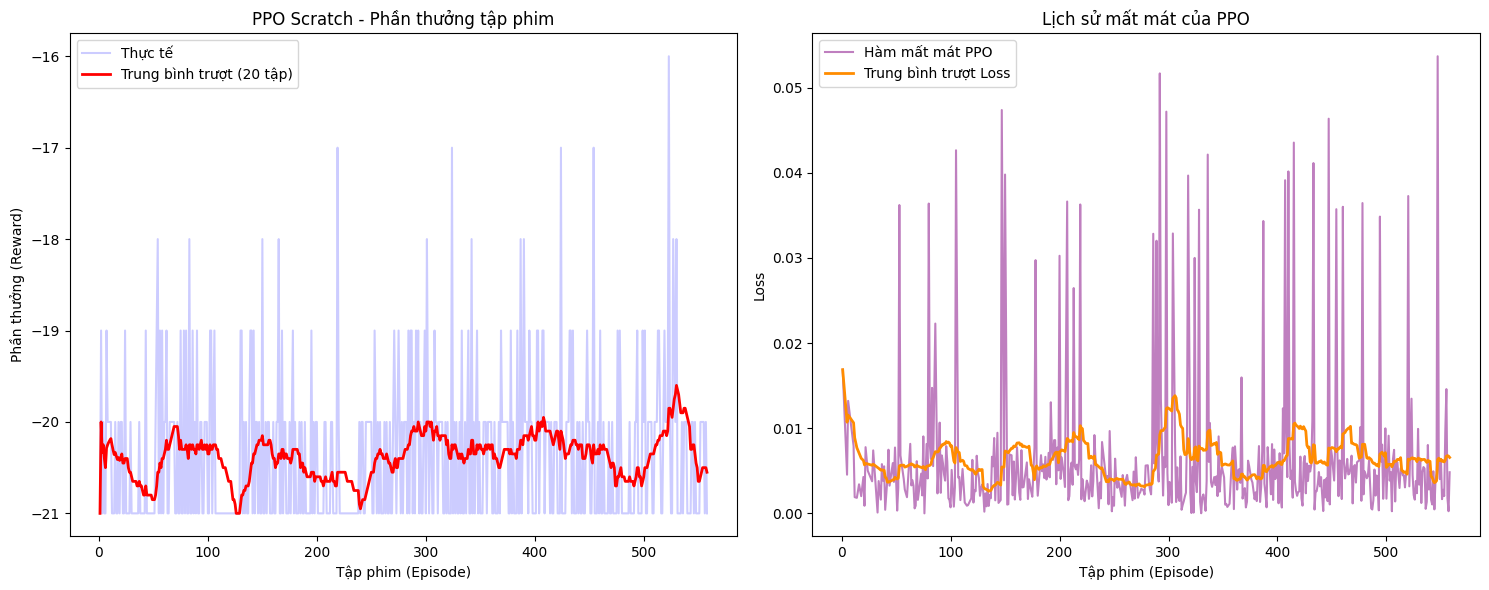

In [7]:
try:
    df = pd.read_csv(csv_file)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Đồ thị phần thưởng
    ax1.plot(df["episode"], df["reward"], alpha=0.2, color="blue", label="Thực tế")
    rolling_rew = df["reward"].rolling(window=20, min_periods=1).mean()
    ax1.plot(df["episode"], rolling_rew, color="red", linewidth=2, label="Trung bình trượt (20 tập)")
    ax1.set_title("PPO Scratch - Phần thưởng tập phim")
    ax1.set_xlabel("Tập phim (Episode)")
    ax1.set_ylabel("Phần thưởng (Reward)")
    ax1.legend()
    
    # Đồ thị PPO loss
    valid_loss_df = df[df["loss"] > 0]
    ax2.plot(valid_loss_df["episode"], valid_loss_df["loss"], color="purple", alpha=0.5, label="Hàm mất mát PPO")
    rolling_loss = valid_loss_df["loss"].rolling(window=20, min_periods=1).mean()
    ax2.plot(valid_loss_df["episode"], rolling_loss, color="darkorange", linewidth=2, label="Trung bình trượt Loss")
    ax2.set_title("Lịch sử mất mát của PPO")
    ax2.set_xlabel("Tập phim (Episode)")
    ax2.set_ylabel("Loss")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Không thể vẽ đồ thị: {e}")